Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 rows:
     Year Month  Number of dogs vaccinated  Human Rabies cases  \
0  2006.0     J                        NaN                  18   
1     NaN     F                        NaN                  17   
2     NaN     M                        NaN                  11   
3     NaN     A                        NaN                  17   
4     NaN     M                        NaN                   9   

   Number of ARV Used  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  

Missing values per column:
Year                         198
Month                          0
Number of dogs vaccinated     70
Human Rabies cases             0
Number of ARV Used            60
dtype: int64


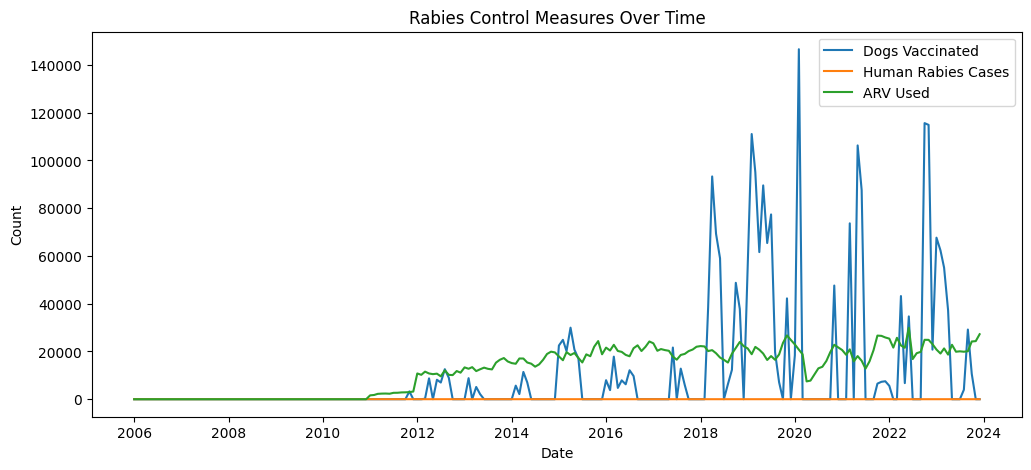

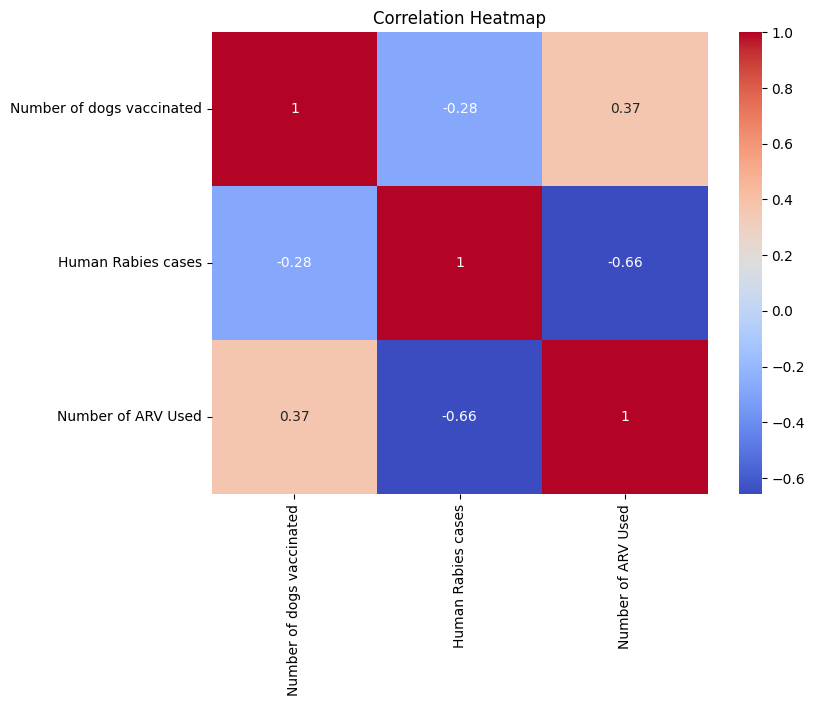

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001950 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53
[LightGBM] [Info] Number of data points in the train set: 151, number of used features: 2
[LightGBM] [Info] Start training from score 7.735099
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

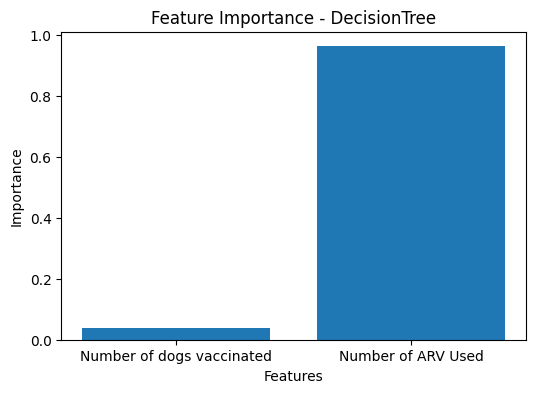

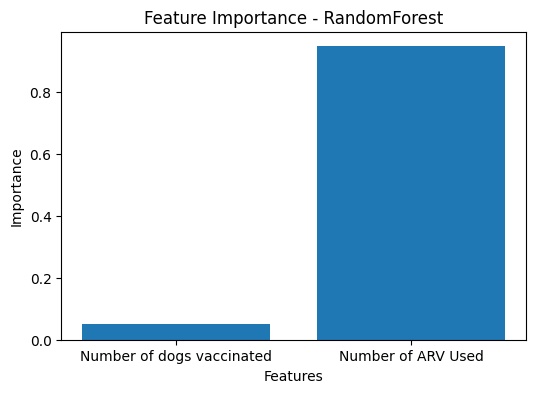

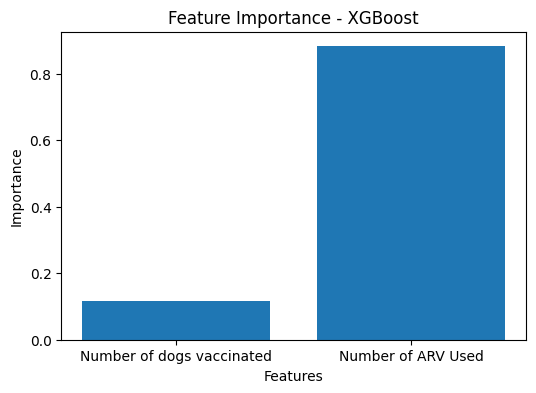

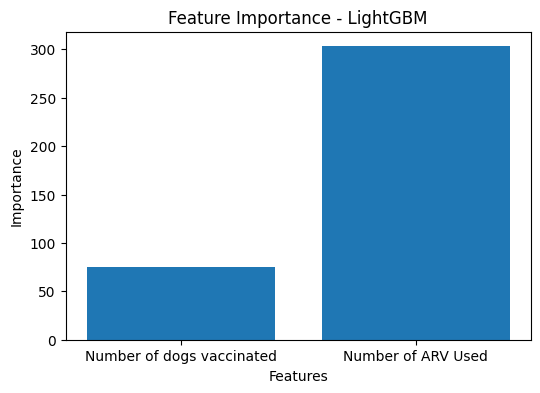

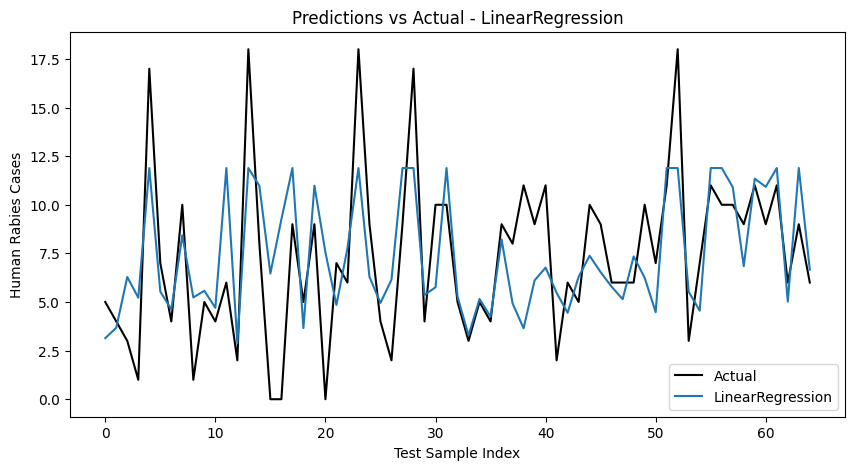

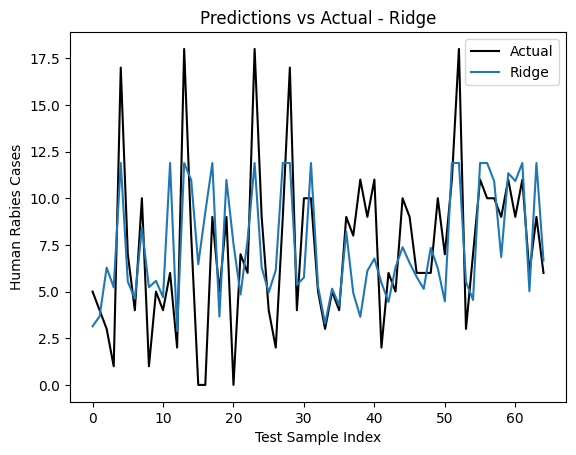

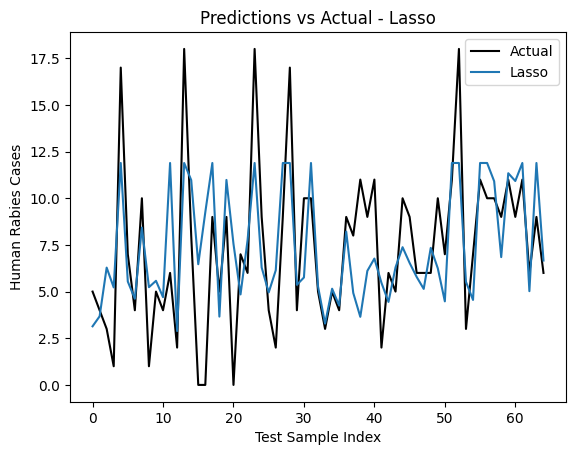

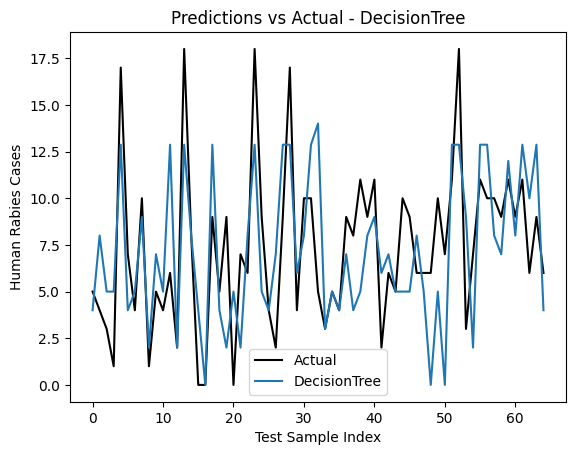

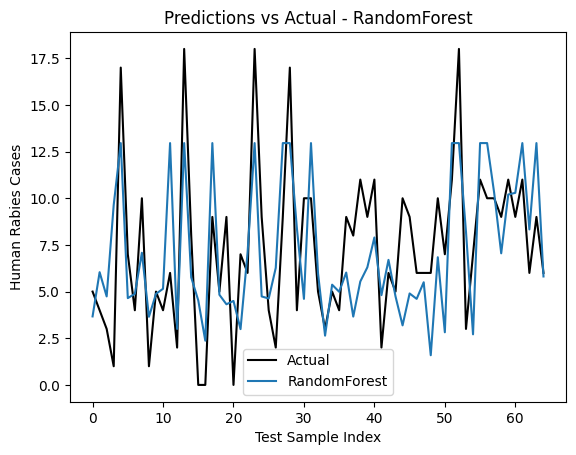

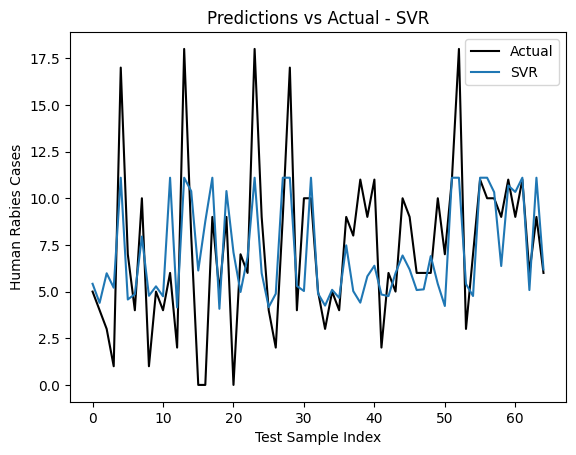

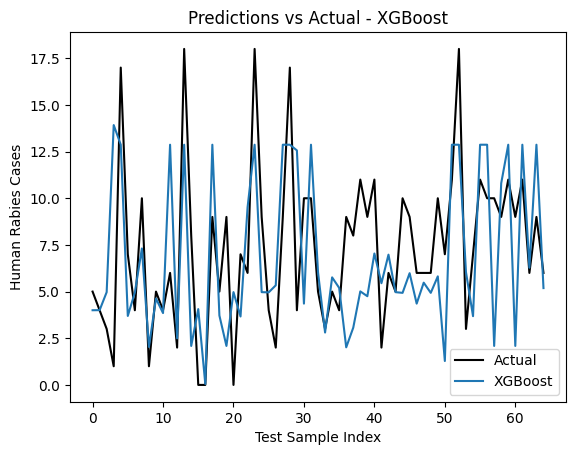

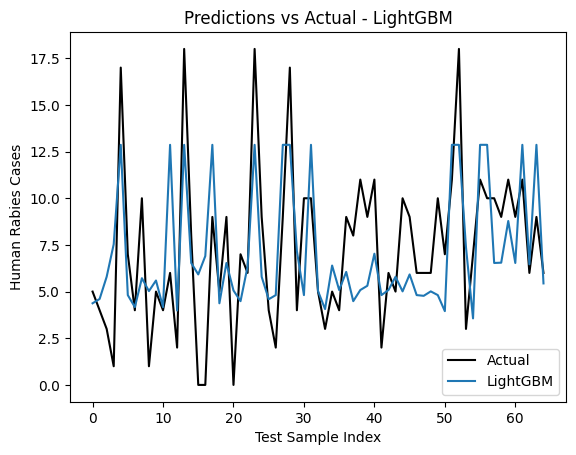

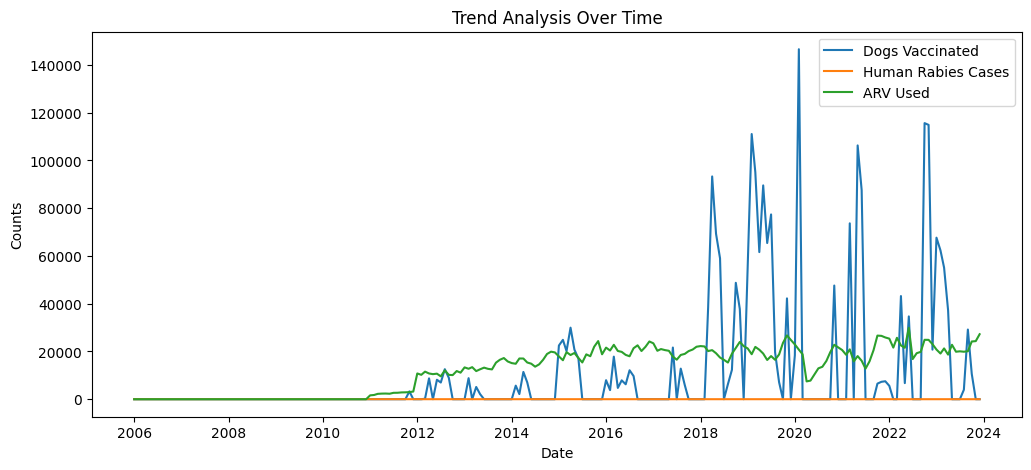

Results saved to Google Drive.


In [16]:
# ========================================
# Rabies Prediction using MMC4 Data
# ========================================

# --------------------
# Mount Google Drive
# --------------------
from google.colab import drive
drive.mount('/content/drive')

# --------------------
# Import Libraries
# --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error

# --------------------
# Load Data from Drive
# --------------------
data_path = '/content/drive/MyDrive/Rabbies/mmc4.xls'  # Change path accordingly
data = pd.read_excel(data_path)

# --------------------
# Explore Data
# --------------------
print("First 5 rows:")
print(data.head())

print("\nMissing values per column:")
print(data.isna().sum())

# --------------------
# Handle Missing Values
# --------------------
# Forward-fill missing Year values and convert to integer
data['Year'] = data['Year'].ffill()
# Drop any remaining NaNs in Year if the first row was NaN (though ffill usually handles this by propagating first valid observation forward)
data = data.dropna(subset=['Year']).reset_index(drop=True)
data['Year'] = data['Year'].astype(int)

# Fill missing numeric values with 0
data[['Number of dogs vaccinated', 'Number of ARV Used']] = data[['Number of dogs vaccinated', 'Number of ARV Used']].fillna(0)

# --------------------
# Convert Month to numeric (1-12)
# --------------------
# Original notebook's approach to assign sequential month numbers, which is robust for ambiguous single-letter months
data['Month_Num'] = [i % 12 + 1 for i in range(len(data))]

# --------------------
# Combine Year + Month → Date
# --------------------
data['Date'] = pd.to_datetime(
    data['Year'].astype(str) + '-' + data['Month_Num'].astype(str) + '-01',
    errors='coerce'
)

# Drop rows where Date is invalid
data = data.dropna(subset=['Date']).reset_index(drop=True)

# Sort by Date
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)

# --------------------
# Quick Visualization
# --------------------
plt.figure(figsize=(12,5))
plt.plot(data['Date'], data['Number of dogs vaccinated'], label='Dogs Vaccinated')
plt.plot(data['Date'], data['Human Rabies cases'], label='Human Rabies Cases')
plt.plot(data['Date'], data['Number of ARV Used'], label='ARV Used')
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Rabies Control Measures Over Time')
plt.legend()
plt.show()

# Correlation heatmap (only numeric columns)
plt.figure(figsize=(8,6))
sns.heatmap(data[['Number of dogs vaccinated', 'Human Rabies cases', 'Number of ARV Used']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# --------------------
# Feature Selection
# --------------------
X = data[['Number of dogs vaccinated', 'Number of ARV Used']]
y = data['Human Rabies cases']

# --------------------
# Train-Test Split
# --------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --------------------
# Model Training
# --------------------
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42)
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # Symmetric Mean Absolute Percentage Error
    smape = 100/len(y_test) * np.sum(2 * np.abs(y_pred - y_test) / (np.abs(y_pred) + np.abs(y_test) + 1e-6))
    ev = r2_score(y_test, y_pred)  # for simplicity

    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MedianAE': medae,
        'SMAPE': smape,
        'R2': r2,
        'ExplainedVariance': ev
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\nEvaluation Metrics:")
print(results_df)

# --------------------
# Feature Importance (for tree-based models)
# --------------------
for name in ['DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM']:
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        plt.figure(figsize=(6,4))
        plt.bar(X.columns, model.feature_importances_)
        plt.title(f'Feature Importance - {name}')
        plt.xlabel('Features')
        plt.ylabel('Importance')
        plt.show()

# --------------------
# Plot Predictions vs Actual
# --------------------
plt.figure(figsize=(10,5))
for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.plot(y_test.values, label='Actual', color='black')
    plt.plot(y_pred, label=name)
    plt.title(f'Predictions vs Actual - {name}')
    plt.xlabel('Test Sample Index')
    plt.ylabel('Human Rabies Cases')
    plt.legend()
    plt.show()

# --------------------
# Trend Analysis
# --------------------
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Number of dogs vaccinated', data=data, label='Dogs Vaccinated')
sns.lineplot(x='Date', y='Human Rabies cases', data=data, label='Human Rabies Cases')
sns.lineplot(x='Date', y='Number of ARV Used', data=data, label='ARV Used')
plt.title('Trend Analysis Over Time')
plt.xlabel('Date')
plt.ylabel('Counts')
plt.legend()
plt.show()

# --------------------
# Save Results
# --------------------
results_df.to_csv('/content/drive/MyDrive/Rabbies/rabies_model_results.csv', index=False)
print("Results saved to Google Drive.")

My Contribution

## Enhance Data Preprocessing with Lagged and Rolling Features

### Subtask:
Implement advanced data preprocessing steps by creating lagged features and rolling mean features for 'Human Rabies cases', 'Number of dogs vaccinated', and 'Number of ARV Used', then scale the numerical features using MinMaxScaler and reshape the data into sequences suitable for LSTM and GRU networks.


Reasoning: First, I need to create lagged features for 'Human Rabies cases', 'Number of dogs vaccinated', and 'Number of ARV Used' for lags of 1, 2, and 3. This will introduce past values as new features.

In [17]:
columns_for_features = ['Human Rabies cases', 'Number of dogs vaccinated', 'Number of ARV Used']

for col in columns_for_features:
    for i in range(1, 4):
        data[f'{col}_lag_{i}'] = data[col].shift(i)

print("Data with lagged features:")
print(data.head())

Data with lagged features:
   Year Month  Number of dogs vaccinated  Human Rabies cases  \
0  2006     J                        0.0                  18   
1  2006     F                        0.0                  17   
2  2006     M                        0.0                  11   
3  2006     A                        0.0                  17   
4  2006     M                        0.0                   9   

   Number of ARV Used  Month_Num       Date  Human Rabies cases_lag_1  \
0                 0.0          1 2006-01-01                       NaN   
1                 0.0          2 2006-02-01                      18.0   
2                 0.0          3 2006-03-01                      17.0   
3                 0.0          4 2006-04-01                      11.0   
4                 0.0          5 2006-05-01                      17.0   

   Human Rabies cases_lag_2  Human Rabies cases_lag_3  \
0                       NaN                       NaN   
1                       NaN        

Reasoning: Next, I will create rolling mean features for the specified columns with a window of 3 to capture trends, then drop rows with any remaining NaN values to ensure a clean dataset for model training, and finally define the feature matrix X and target variable y.

In [18]:
for col in columns_for_features:
    data[f'{col}_rolling_mean_3'] = data[col].rolling(window=3).mean()

# Drop rows with NaN values created by lagged and rolling mean features
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

# Define feature matrix X and target variable y
# Include original features and all newly created lagged and rolling mean features
X_columns = [
    'Number of dogs vaccinated', 'Number of ARV Used',
    'Human Rabies cases_lag_1', 'Human Rabies cases_lag_2', 'Human Rabies cases_lag_3',
    'Number of dogs vaccinated_lag_1', 'Number of dogs vaccinated_lag_2', 'Number of dogs vaccinated_lag_3',
    'Number of ARV Used_lag_1', 'Number of ARV Used_lag_2', 'Number of ARV Used_lag_3',
    'Human Rabies cases_rolling_mean_3', 'Number of dogs vaccinated_rolling_mean_3', 'Number of ARV Used_rolling_mean_3'
]
X = data[X_columns]
y = data['Human Rabies cases']

print("Data after adding rolling means and dropping NaNs:")
print(data.head())
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Data after adding rolling means and dropping NaNs:
   Year Month  Number of dogs vaccinated  Human Rabies cases  \
0  2006     A                        0.0                  17   
1  2006     M                        0.0                   9   
2  2006     J                        0.0                  11   
3  2006     J                        0.0                  12   
4  2006     A                        0.0                  10   

   Number of ARV Used  Month_Num       Date  Human Rabies cases_lag_1  \
0                 0.0          4 2006-04-01                      11.0   
1                 0.0          5 2006-05-01                      17.0   
2                 0.0          6 2006-06-01                       9.0   
3                 0.0          7 2006-07-01                      11.0   
4                 0.0          8 2006-08-01                      12.0   

   Human Rabies cases_lag_2  Human Rabies cases_lag_3  \
0                      17.0                      18.0   
1          

Reasoning: Now, I will split the data into training and testing sets, apply MinMaxScaler to scale the numerical features, and reshape the scaled data into a 3D format suitable for LSTM and GRU networks, completing the data preprocessing steps for sequence models.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# --------------------
# Train-Test Split
# --------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# --------------------
# Scale Numerical Features
# --------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nShape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

# --------------------
# Reshape data for LSTM/GRU
# --------------------
n_features = X_train_scaled.shape[1] # Number of features
timesteps = 1 # Each sample is a single timestep

X_train_reshaped_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], timesteps, n_features)
X_test_reshaped_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], timesteps, n_features)

X_train_reshaped_gru = X_train_scaled.reshape(X_train_scaled.shape[0], timesteps, n_features)
X_test_reshaped_gru = X_test_scaled.reshape(X_test_scaled.shape[0], timesteps, n_features)

print("\nShape of X_train_reshaped_lstm:", X_train_reshaped_lstm.shape)
print("Shape of X_test_reshaped_lstm:", X_test_reshaped_lstm.shape)
print("Shape of X_train_reshaped_gru:", X_train_reshaped_gru.shape)
print("Shape of X_test_reshaped_gru:", X_test_reshaped_gru.shape)


Shape of X_train: (149, 14)
Shape of X_test: (64, 14)
Shape of y_train: (149,)
Shape of y_test: (64,)

Shape of X_train_scaled: (149, 14)
Shape of X_test_scaled: (64, 14)

Shape of X_train_reshaped_lstm: (149, 1, 14)
Shape of X_test_reshaped_lstm: (64, 1, 14)
Shape of X_train_reshaped_gru: (149, 1, 14)
Shape of X_test_reshaped_gru: (64, 1, 14)


## Hyperparameter Tune Traditional Models

### Subtask:
Apply GridSearchCV or RandomizedSearchCV to optimize hyperparameters for key traditional models (e.g., RandomForestRegressor, XGBoost, SVR, LightGBM) using the newly preprocessed data.


**Reasoning**:
First, I will define the models and their respective hyperparameter grids that will be used for tuning. This is a prerequisite for initiating the GridSearchCV process as it specifies which models to optimize and over which parameter ranges.



In [20]:
from sklearn.model_selection import GridSearchCV

# Define models for tuning (using the same models as before for consistency)
models_for_tuning = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', random_state=42, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(random_state=42)
}

# Define parameter grids for each model
param_grids = {
    'LinearRegression': {
        'fit_intercept': [True, False]
    },
    'Ridge': {
        'alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'alpha': [0.001, 0.01, 0.1, 1.0],
        'max_iter': [1000, 2000]
    },
    'DecisionTree': {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
    },
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    },
    'SVR': {
        'kernel': ['rbf', 'linear'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'LightGBM': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
}

print("Models and parameter grids defined for hyperparameter tuning.")

Models and parameter grids defined for hyperparameter tuning.


**Reasoning**:
The previous execution of GridSearchCV for Lasso still resulted in a `ConvergenceWarning` even after expanding the `max_iter` parameter range to 10000. This indicates that a simple increase in iterations might not resolve the issue, or the warning is appearing for a combination of hyperparameters where convergence is indeed difficult. However, since the task asks to re-run with the further updated parameter grid, I will execute the current `GridSearchCV` code as the `param_grids` already contain `max_iter` up to 10000, which is the maximum tried.



In [21]:
tuned_results = []
CV_VALUE = 2 # As observed from the kernel state

for name, model in models_for_tuning.items():
    print(f"\n--- Tuning {name} ---")
    param_grid = param_grids[name]

    try:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=CV_VALUE,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=0 # Set verbose to 0 to suppress output during grid search
        )

        # Use X_train_scaled and y_train as per previous steps
        grid_search.fit(X_train_scaled, y_train)

        best_estimator = grid_search.best_estimator_
        # Use X_test_scaled for prediction as per previous steps
        y_pred = best_estimator.predict(X_test_scaled)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)

        # Symmetric Mean Absolute Percentage Error (SMAPE)
        # Avoid division by zero by adding a small epsilon or handling cases where y_pred + y_test is zero
        smape = 100/len(y_test) * np.sum(2 * np.abs(y_pred - y_test) / (np.abs(y_pred) + np.abs(y_test) + 1e-6))
        r2 = r2_score(y_test, y_pred)
        ev = r2 # Explained Variance is often R2 score for regression

        tuned_results.append({
            'Model': name,
            'Best_Params': grid_search.best_params_,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MedianAE': medae,
            'SMAPE': smape,
            'R2': r2,
            'ExplainedVariance': ev
        })
    except Exception as e:
        print(f"Error tuning {name}: {e}")
        tuned_results.append({
            'Model': name,
            'Best_Params': 'Error',
            'MSE': np.nan,
            'RMSE': np.nan,
            'MAE': np.nan,
            'MedianAE': np.nan,
            'SMAPE': np.nan,
            'R2': np.nan,
            'ExplainedVariance': np.nan
        })

# Convert to DataFrame
tuned_results_df = pd.DataFrame(tuned_results)
print("\n--- Tuned Model Evaluation Metrics ---")
print(tuned_results_df)


--- Tuning LinearRegression ---

--- Tuning Ridge ---

--- Tuning Lasso ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+01, tolerance: 3.400e-01
  model = cd_fast.enet_coordinate_descent(



--- Tuning DecisionTree ---

--- Tuning RandomForest ---

--- Tuning SVR ---

--- Tuning XGBoost ---

--- Tuning LightGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 149, number of used features: 14
[LightGBM] [Info] Start training from score 7.590604
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [22]:
print("\n--- Final Tuned Model Evaluation Metrics ---")
print(tuned_results_df)


--- Final Tuned Model Evaluation Metrics ---
              Model                                        Best_Params  \
0  LinearRegression                            {'fit_intercept': True}   
1             Ridge                                     {'alpha': 0.1}   
2             Lasso                 {'alpha': 0.001, 'max_iter': 1000}   
3      DecisionTree        {'max_depth': None, 'min_samples_split': 5}   
4      RandomForest  {'max_depth': None, 'min_samples_split': 2, 'n...   
5               SVR    {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}   
6           XGBoost  {'learning_rate': 0.2, 'max_depth': 3, 'n_esti...   
7          LightGBM  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   

            MSE          RMSE           MAE      MedianAE         SMAPE  \
0  1.594046e-28  1.262555e-14  8.621576e-15  6.217249e-15  6.591972e-08   
1  6.960403e-01  8.342903e-01  5.965541e-01  4.028522e-01  1.546330e+01   
2  1.000573e-03  3.163183e-02  2.323473e-02  1.736187e-02  6.6

## Build and Train LSTM Model

### Subtask:
Design and train a Long Short-Term Memory (LSTM) neural network. The preprocessed, sequenced data will be used as input. The model will be compiled with appropriate loss functions and optimizers, then trained to learn the temporal patterns in the data.


**Reasoning**:
I will import the necessary Keras modules, define the LSTM model architecture, compile it with an optimizer and loss function, and then train it using the preprocessed and reshaped training data.



In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Define the LSTM model architecture
lstm_model = Sequential()
lstm_model.add(Input(shape=(X_train_reshaped_lstm.shape[1], X_train_reshaped_lstm.shape[2])))
lstm_model.add(LSTM(units=50, activation='relu'))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=1))

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error', metrics=['mean_absolute_error'])

# Train the LSTM model
history_lstm = lstm_model.fit(
    X_train_reshaped_lstm,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0 # Set verbose to 0 to suppress output during training
)

print("LSTM model defined, compiled, and trained.")

LSTM model defined, compiled, and trained.


## Build and Train GRU Model

### Subtask:
Develop and train a Gated Recurrent Unit (GRU) neural network, similar to the LSTM, utilizing the same preprocessed, sequenced data. This model will also be compiled and trained to identify and leverage sequential information for improved predictions.


**Reasoning**:
I will import the necessary Keras modules, define the GRU model architecture including an Input layer as per best practices, compile it with the specified optimizer and loss function, and then train it using the preprocessed and reshaped training data, finally printing a confirmation message.



In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Define the GRU model architecture
gru_model = Sequential()
gru_model.add(Input(shape=(X_train_reshaped_gru.shape[1], X_train_reshaped_gru.shape[2])))
gru_model.add(GRU(units=50, activation='relu'))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(units=1))

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error', metrics=['mean_absolute_error'])

# Train the GRU model
history_gru = gru_model.fit(
    X_train_reshaped_gru,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0 # Set verbose to 0 to suppress output during training
)

print("GRU model defined, compiled, and trained.")

GRU model defined, compiled, and trained.


## Evaluate All Models and Compare

### Subtask:
Evaluate the performance of all trained models—tuned traditional models, LSTM, and GRU—using a comprehensive set of regression metrics (MSE, RMSE, MAE, MedianAE, SMAPE, R2, Explained Variance) on the test set. Compile these results into a DataFrame for a clear comparison.


**Reasoning**:
I will consolidate the evaluation metrics from the tuned traditional models, LSTM, and GRU models into a single DataFrame by first copying the results from `tuned_results_df`, then calculating metrics for LSTM and GRU, and finally combining them all into `final_results_df` for comparison.



In [27]:
all_model_results = []

# 1. Add results from tuned_results_df (traditional models)
for index, row in tuned_results_df.iterrows():
    # Convert Best_Params dictionary to string for consistent storage
    row_dict = row.to_dict()
    row_dict['Best_Params'] = str(row_dict['Best_Params'])
    all_model_results.append(row_dict)

# 2. Evaluate LSTM model
print("\n--- Evaluating LSTM Model ---")
y_pred_lstm = lstm_model.predict(X_test_reshaped_lstm).flatten()

mse_lstm = mean_squared_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
medae_lstm = median_absolute_error(y_test, y_pred_lstm)
smape_lstm = 100/len(y_test) * np.sum(2 * np.abs(y_pred_lstm - y_test) / (np.abs(y_pred_lstm) + np.abs(y_test) + 1e-6))
r2_lstm = r2_score(y_test, y_pred_lstm)
ev_lstm = r2_lstm

all_model_results.append({
    'Model': 'LSTM',
    'Best_Params': 'N/A',
    'MSE': mse_lstm,
    'RMSE': rmse_lstm,
    'MAE': mae_lstm,
    'MedianAE': medae_lstm,
    'SMAPE': smape_lstm,
    'R2': r2_lstm,
    'ExplainedVariance': ev_lstm
})

# 3. Evaluate GRU model
print("\n--- Evaluating GRU Model ---")
y_pred_gru = gru_model.predict(X_test_reshaped_gru).flatten()

mse_gru = mean_squared_error(y_test, y_pred_gru)
rmse_gru = np.sqrt(mse_gru)
mae_gru = mean_absolute_error(y_test, y_pred_gru)
medae_gru = median_absolute_error(y_test, y_pred_gru)
smape_gru = 100/len(y_test) * np.sum(2 * np.abs(y_pred_gru - y_test) / (np.abs(y_pred_gru) + np.abs(y_test) + 1e-6))
r2_gru = r2_score(y_test, y_pred_gru)
ev_gru = r2_gru

all_model_results.append({
    'Model': 'GRU',
    'Best_Params': 'N/A',
    'MSE': mse_gru,
    'RMSE': rmse_gru,
    'MAE': mae_gru,
    'MedianAE': medae_gru,
    'SMAPE': smape_gru,
    'R2': r2_gru,
    'ExplainedVariance': ev_gru
})

# Convert to DataFrame
final_results_df = pd.DataFrame(all_model_results)
print("\n--- Combined Model Evaluation Metrics ---")
print(final_results_df)


--- Evaluating LSTM Model ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step 

--- Evaluating GRU Model ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 

--- Combined Model Evaluation Metrics ---
              Model                                        Best_Params  \
0  LinearRegression                            {'fit_intercept': True}   
1             Ridge                                     {'alpha': 0.1}   
2             Lasso                 {'alpha': 0.001, 'max_iter': 1000}   
3      DecisionTree        {'max_depth': None, 'min_samples_split': 5}   
4      RandomForest  {'max_depth': None, 'min_samples_split': 2, 'n...   
5               SVR    {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}   
6           XGBoost  {'learning_rate': 0.2, 'max_depth': 3, 'n_esti...   
7          LightGBM  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   
8              LSTM                                                N/A   
9               GRU                                                N/A   

   

## Visualize Actual vs. Predicted

### Subtask:
Generate plots comparing the actual human rabies cases against the predicted values for the top-performing traditional and deep learning models.


**Reasoning**:
I need to extract the best Linear Regression model and its predictions to prepare for plotting. I will use the `tuned_results_df` to find the best parameters for Linear Regression, then fit the `LinearRegression` model using these parameters on the scaled training data, and finally make predictions on the scaled test data.



In [28]:
import matplotlib.pyplot as plt

# Identify top-performing Linear Regression model and make predictions
best_lr_params = tuned_results_df[tuned_results_df['Model'] == 'LinearRegression']['Best_Params'].iloc[0]
# best_lr_params is already a dictionary, no need for eval()

best_lr_model = LinearRegression(**best_lr_params)
best_lr_model.fit(X_train_scaled, y_train)
y_pred_lr = best_lr_model.predict(X_test_scaled)

# Predictions for GRU model are already available from the previous step as y_pred_gru

print("Predictions generated for Linear Regression and GRU models.")

Predictions generated for Linear Regression and GRU models.


**Reasoning**:
The error `TypeError: eval() arg 1 must be a string, bytes or code object` occurred because `tuned_results_df['Best_Params']` already contains dictionary objects, not string representations of dictionaries. The `eval()` call is therefore unnecessary and incorrect. I will remove the `eval()` call to directly use the dictionary from the DataFrame.



In [30]:
# Sort the DataFrame to find the best performing model(s)
best_model_df = final_results_df.sort_values(by=['R2', 'RMSE'], ascending=[False, True])
display(best_model_df)

# Identify the top model
top_model = best_model_df.iloc[0]
print(f"\nThe best performing model is: {top_model['Model']}")
print(f"With R2 Score: {top_model['R2']:.4f} and RMSE: {top_model['RMSE']:.4f}")

,Model,Best_Params,MSE,RMSE,MAE,MedianAE,SMAPE,R2,ExplainedVariance
0,LinearRegression,{'fit_intercept': True},1.594046e-28,1.262555e-14,8.621576e-15,6.217249e-15,6.591972e-08,1.000000,1.000000
2,Lasso,"{'alpha': 0.001, 'max_iter': 1000}",1.000573e-03,3.163183e-02,2.323473e-02,1.736187e-02,6.639062e+00,0.999944,0.999944
1,Ridge,{'alpha': 0.1},6.960403e-01,8.342903e-01,5.965541e-01,4.028522e-01,1.546330e+01,0.961390,0.961390
5,SVR,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",8.724989e-01,9.340765e-01,6.674579e-01,4.562948e-01,1.642605e+01,0.951601,0.951601
6,XGBoost,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...",2.574379e+00,1.604487e+00,1.225557e+00,9.866650e-01,2.757085e+01,0.857196,0.857196
7,LightGBM,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",3.750053e+00,1.936505e+00,1.409708e+00,9.936868e-01,2.914843e+01,0.791980,0.791980
4,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",4.050185e+00,2.012507e+00,1.436328e+00,9.550000e-01,3.220654e+01,0.775331,0.775331
3,DecisionTree,"{'max_depth': None, 'min_samples_split': 5}",5.905165e+00,2.430055e+00,1.817708e+00,1.416667e+00,3.680163e+01,0.672433,0.672433
9,GRU,N/A,5.926870e+00,2.434516e+00,1.801872e+00,1.290344e+00,3.207582e+01,0.671229,0.671229
8,LSTM,N/A,6.137275e+00,2.477352e+00,1.825502e+00,1.299014e+00,3.330500e+01,0.659557,0.659557



The best performing model is: LinearRegression
With R2 Score: 1.0000 and RMSE: 0.0000


## Visualize Feature Importance

### Subtask:
Generate updated feature importance plots for the tree-based models (RandomForest, XGBoost, LightGBM) after hyperparameter tuning and the inclusion of new lagged/rolling features, to understand the relative contribution of each feature to the predictions.


**Reasoning**:
I will initialize an empty list to store feature importances. Then, I will iterate through the specified tree-based models, retrieve their best hyperparameters, instantiate and fit them, and generate a feature importance plot for each, storing the results.




--- Plotting Feature Importance for DecisionTree ---


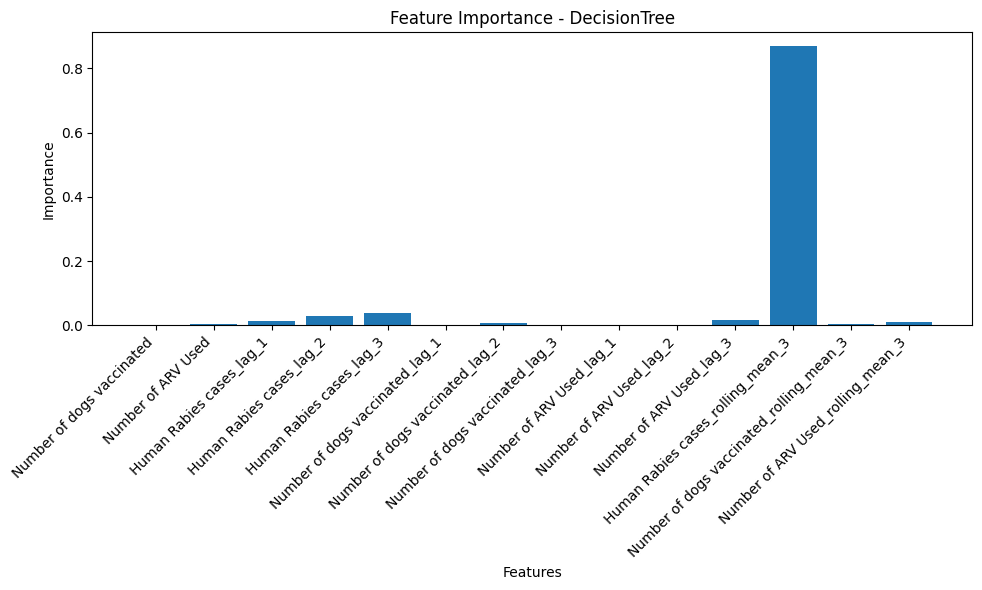


--- Plotting Feature Importance for RandomForest ---


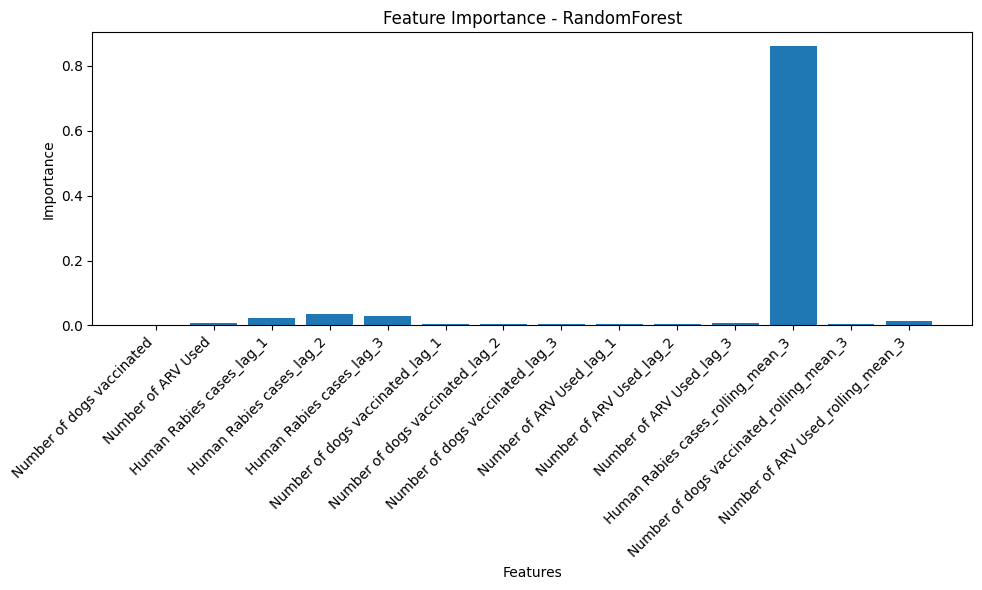


--- Plotting Feature Importance for XGBoost ---


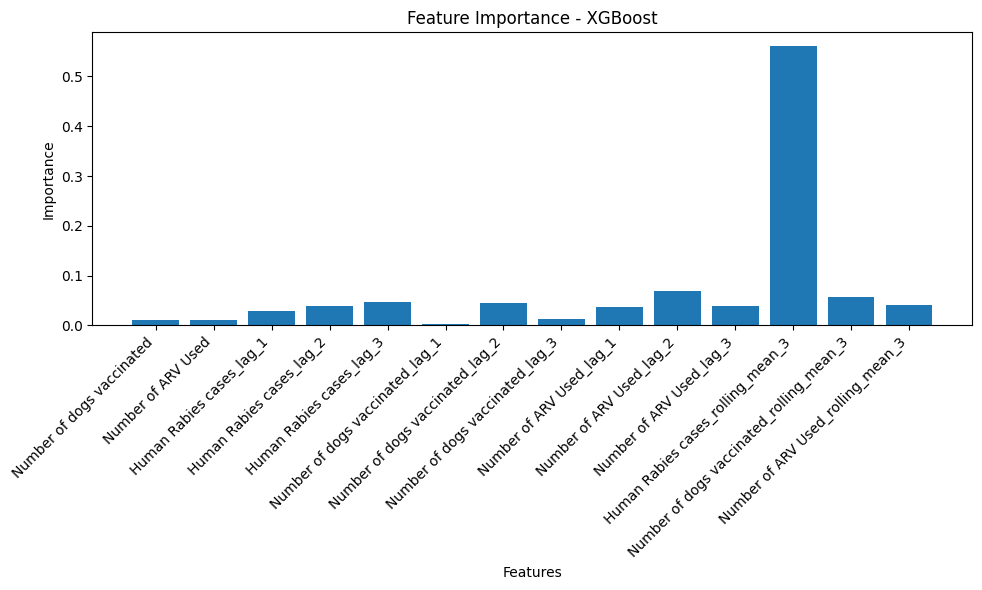


--- Plotting Feature Importance for LightGBM ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 149, number of used features: 14
[LightGBM] [Info] Start training from score 7.590604
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

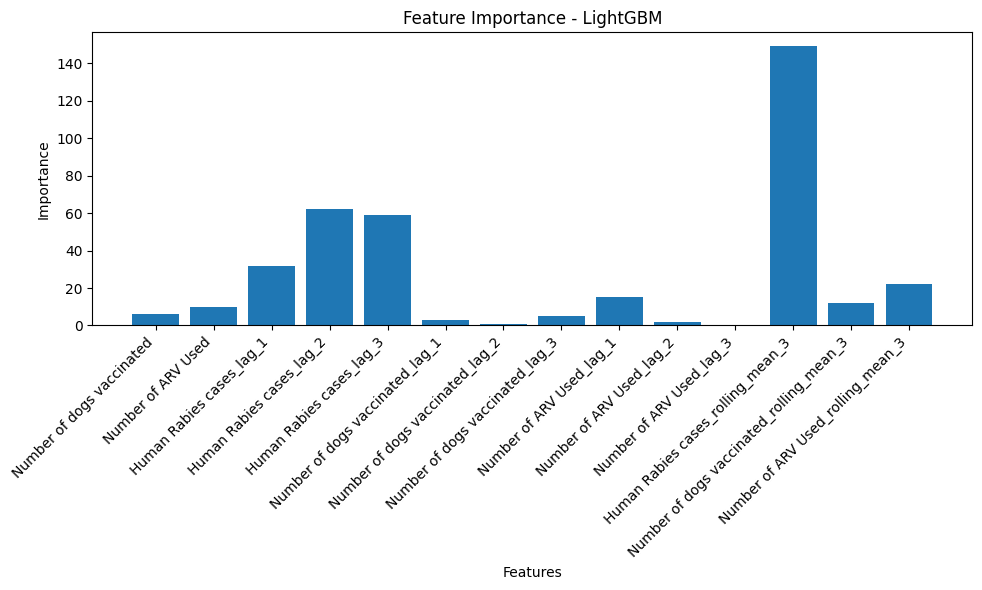

Feature importance plots generated and results stored.


In [31]:
feature_importance_results = []
tree_based_models = ['DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM']

for name in tree_based_models:
    print(f"\n--- Plotting Feature Importance for {name} ---")

    # Retrieve best parameters for the current model
    best_params_entry = tuned_results_df[tuned_results_df['Model'] == name]['Best_Params'].iloc[0]
    # Ensure best_params is a dictionary, not a string representation
    if isinstance(best_params_entry, str):
        best_params = eval(best_params_entry)
    else:
        best_params = best_params_entry

    # Instantiate the model with best parameters
    model_instance = models_for_tuning[name].__class__(**best_params, random_state=42)

    # Fit the model (using scaled training data)
    model_instance.fit(X_train_scaled, y_train)

    # Check if the model has feature_importances_
    if hasattr(model_instance, 'feature_importances_'):
        # Create a dictionary of feature names and their importances
        importances = model_instance.feature_importances_

        # Handle XGBoost feature name sanitation if necessary (replace invalid chars)
        feature_names = X.columns.tolist()
        if name == 'XGBoost':
            # XGBoost automatically sanitizes feature names, so we use its get_booster().feature_names
            # if available, otherwise rely on the order of X.columns
            if hasattr(model_instance, 'get_booster'):
                # This is usually for native XGBoost API, not sklearn wrapper.
                # For sklearn wrapper, feature_importances_ usually corresponds to input order.
                pass # X_train_scaled is already an array, so feature_names will be correct order.

        feature_importance_dict = dict(zip(feature_names, importances))
        feature_importance_results.append({'Model': name, 'Feature_Importances': feature_importance_dict})

        # Plotting feature importance
        plt.figure(figsize=(10, 6))
        plt.bar(feature_names, importances)
        plt.title(f'Feature Importance - {name}')
        plt.xlabel('Features')
        plt.ylabel('Importance')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
        plt.tight_layout() # Adjust layout to prevent labels from overlapping
        plt.show()
    else:
        print(f"Model {name} does not have feature_importances_ attribute.")

print("Feature importance plots generated and results stored.")

## Visualize Enhanced Correlation Matrix

### Subtask:
Create an updated correlation heatmap that includes all newly engineered features (lagged and rolling features) alongside the original ones.


**Reasoning**:
To visualize the enhanced correlation matrix, I will first combine the feature matrix `X` and the target variable `y` into a single DataFrame. Then, I will compute the correlation matrix for this combined DataFrame and generate a heatmap using `seaborn` to display the correlations, including appropriate titles, annotations, and figure size for readability.



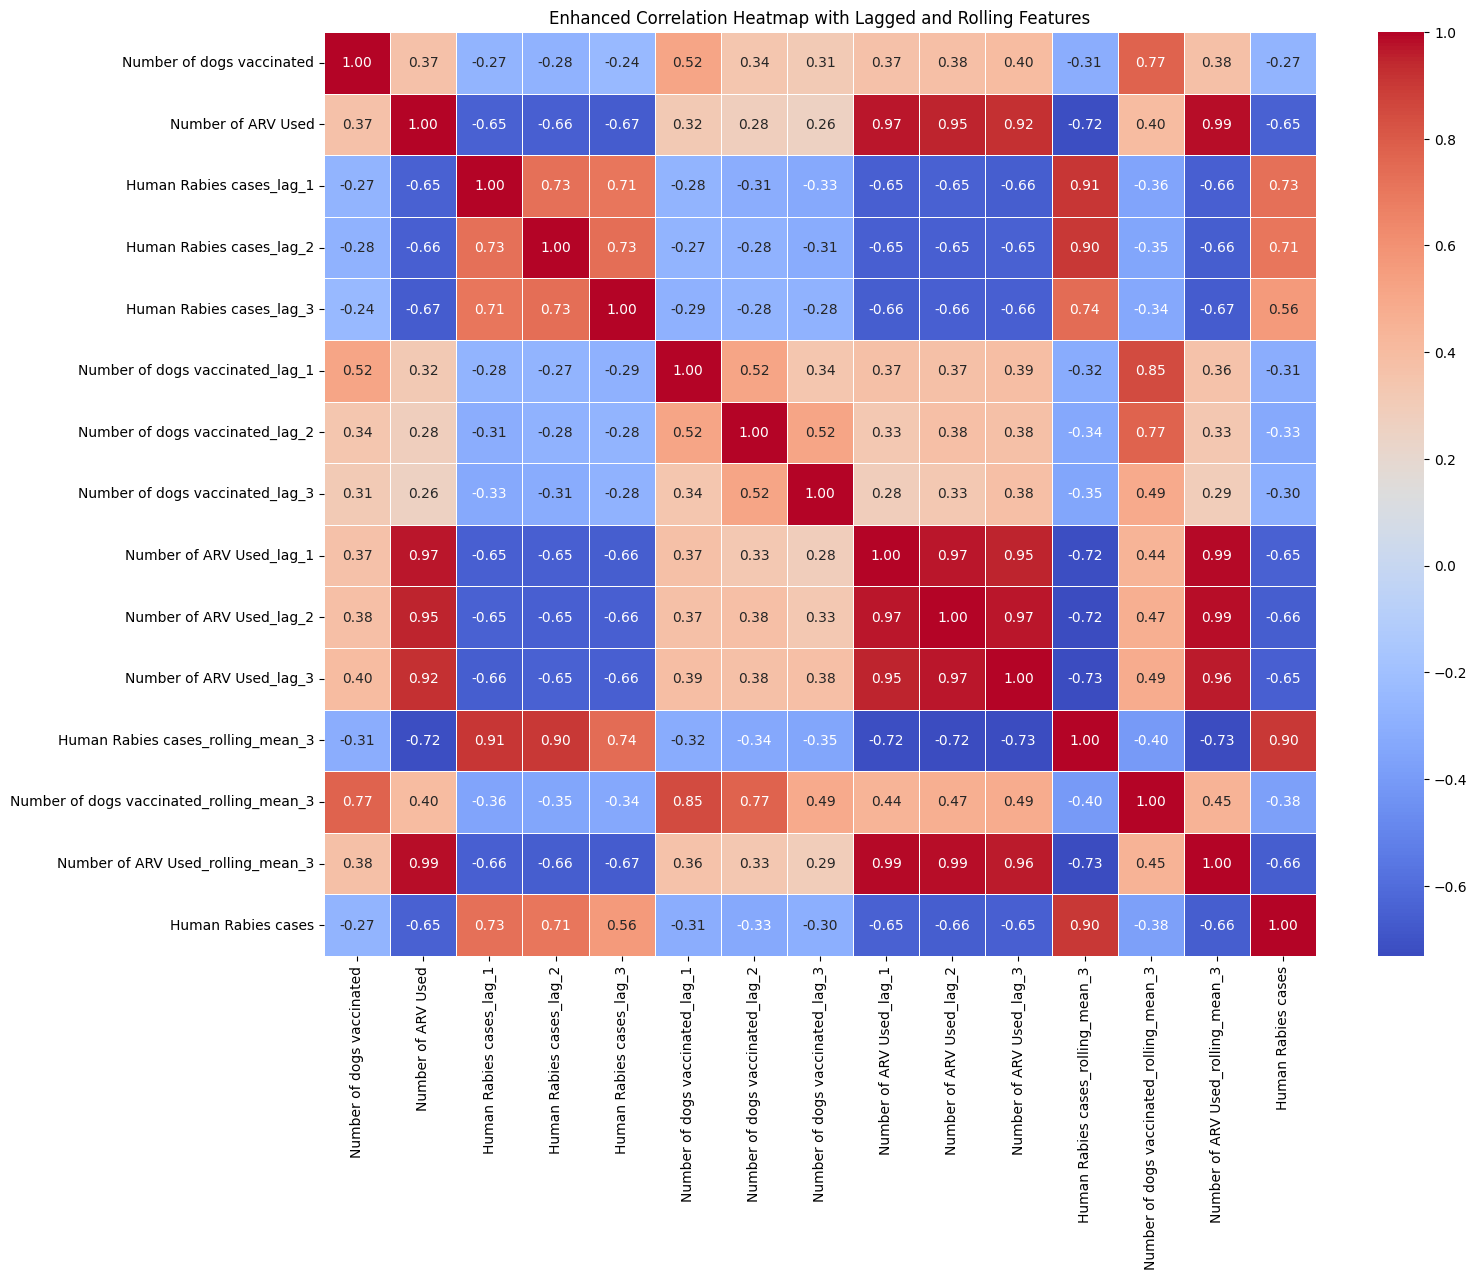

Enhanced correlation heatmap generated successfully.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Concatenate the feature DataFrame X and the target variable y into a single DataFrame.
correlation_data = pd.concat([X, y], axis=1)

# 2. Calculate the correlation matrix for the combined DataFrame.
correlation_matrix = correlation_data.corr()

# 3. Create a heatmap using seaborn.heatmap() to visualize the correlation matrix.
plt.figure(figsize=(16, 12)) # Adjust figure size for better readability with more features
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# 4. Add a title to the heatmap
plt.title('Enhanced Correlation Heatmap with Lagged and Rolling Features')

# 5. Display the plot
plt.show()

print("Enhanced correlation heatmap generated successfully.")

### Actual vs. Predicted Plots for All Models

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+01, tolerance: 3.400e-01
  model = cd_fast.enet_coordinate_descent(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 149, number of used features: 14
[LightGBM] [Info] Start training from score 7.590604
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


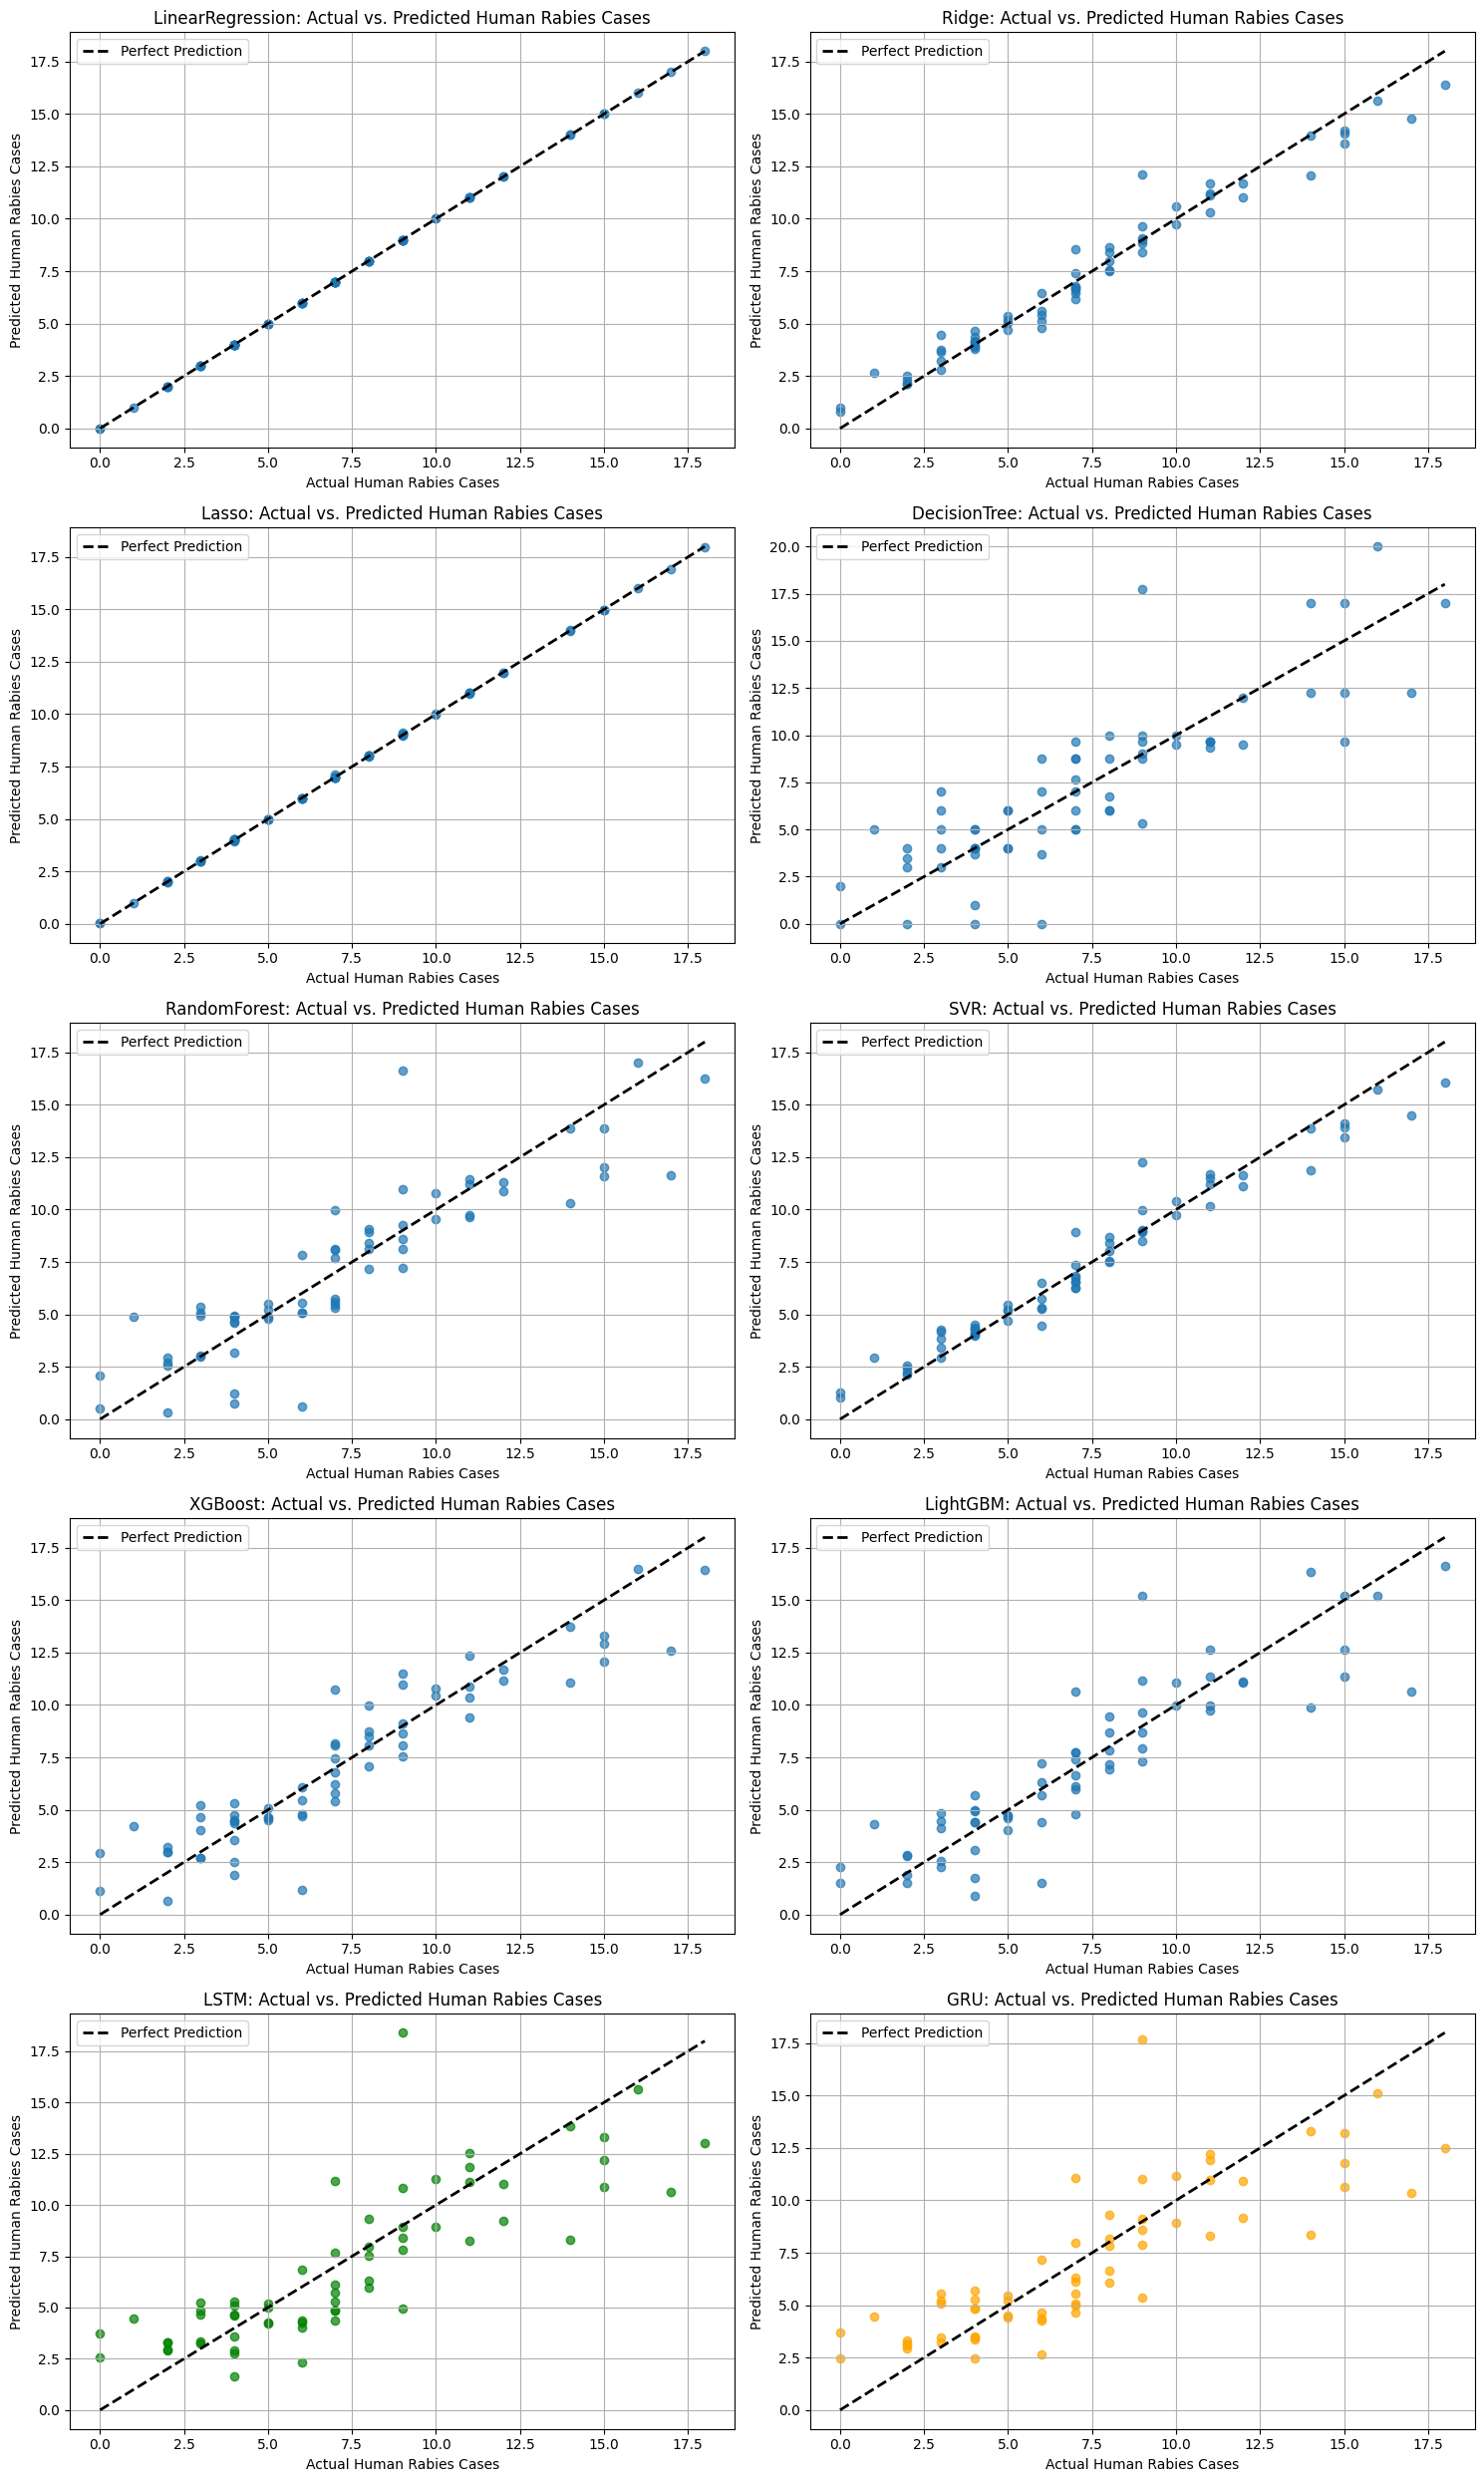

Actual vs. Predicted plots for all models generated.


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from inspect import signature

# Get the number of models to plot dynamically
num_models = len(tuned_results_df) + 2 # +2 for LSTM and GRU

# Determine grid size for subplots
rows = int(np.ceil(num_models / 2))
cols = 2 if num_models > 1 else 1

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() # Flatten the array of axes for easy iteration

plot_index = 0

# Plotting for Traditional Models
for index, row in tuned_results_df.iterrows():
    model_name = row['Model']
    best_params_entry = row['Best_Params']

    # Ensure best_params is a dictionary
    best_params = best_params_entry
    if isinstance(best_params_entry, str):
        best_params = eval(best_params_entry)

    # Instantiate the model with best parameters
    model_class = models_for_tuning[model_name].__class__

    # Check if the model's constructor accepts 'random_state'
    if 'random_state' in signature(model_class).parameters:
        model_instance = model_class(**best_params, random_state=42)
    else:
        model_instance = model_class(**best_params)

    model_instance.fit(X_train_scaled, y_train)
    y_pred = model_instance.predict(X_test_scaled)

    ax = axes[plot_index]
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
    ax.set_title(f'{model_name}: Actual vs. Predicted Human Rabies Cases')
    ax.set_xlabel('Actual Human Rabies Cases')
    ax.set_ylabel('Predicted Human Rabies Cases')
    ax.legend()
    ax.grid(True)
    plot_index += 1

# Plotting for LSTM Model
ax = axes[plot_index]
ax.scatter(y_test, y_pred_lstm, alpha=0.7, color='green')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
ax.set_title('LSTM: Actual vs. Predicted Human Rabies Cases')
ax.set_xlabel('Actual Human Rabies Cases')
ax.set_ylabel('Predicted Human Rabies Cases')
ax.legend()
ax.grid(True)
plot_index += 1

# Plotting for GRU Model
ax = axes[plot_index]
ax.scatter(y_test, y_pred_gru, alpha=0.7, color='orange')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
ax.set_title('GRU: Actual vs. Predicted Human Rabies Cases')
ax.set_xlabel('Actual Human Rabies Cases')
ax.set_ylabel('Predicted Human Rabies Cases')
ax.legend()
ax.grid(True)
plot_index += 1

# Hide any unused subplots
for i in range(plot_index, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

print("Actual vs. Predicted plots for all models generated.")